# Tohoku Tsunami — Open Elevation Data

This notebook runs the 2011 Tohoku tsunami simulation using **freely available**
global bathymetry/topography instead of the proprietary `Tohoku.pts` file.

Elevation source: **NOAA NCEI Global DEM Mosaic** (GEBCO-based), downloaded via
the ArcGIS ImageServer REST API — no registration or API key required.
- 15 arc-second (~450 m) resolution
- Land topography (SRTM-derived) + ocean bathymetry (GEBCO)
- Coverage: global

Earthquake source: KL random slip field (Karhunen–Loève expansion) via `okada_kl_subfaults`.

Gauge data from https://www.ngdc.noaa.gov/hazard/dart/2011honshu_dart.html

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import anuga
import okada_kl_subfaults as okl

%matplotlib inline
%load_ext autoreload
%autoreload 2

from matplotlib import rc
rc('animation', html='jshtml')

In [2]:
try:
    os.chdir('Tohoku')
except:
    pass
print(f'Working directory: {os.getcwd()}')

Working directory: /home/steve/Tohoku


## Download Elevation Data

Downloads a GeoTIFF covering the simulation domain from the NOAA NCEI Global DEM
Mosaic.  The file is ~19 MB and is skipped on subsequent runs if it already exists.

In [3]:
from download_elevation import download_noaa_dem

dem_file = 'Tohoku_dem.tif'

if not os.path.exists(dem_file):
    download_noaa_dem(dem_file, resolution_arcsec=15, padding_deg=0.5, verbose=True)
else:
    print(f'Using existing {dem_file}')

Using existing Tohoku_dem.tif


## Gauge Locations

In [4]:
import utm

class Gauge:
    def __init__(self, long, lat, t1=0.0, t2=1.e10):
        self.lat  = lat
        self.long = long
        self.t1   = t1
        self.t2   = t2
        east, north, zone_no, zone_letter = utm.from_latlon(lat, long, force_zone_number=54)
        self.east        = east
        self.north       = north
        self.zone_no     = zone_no
        self.zone_letter = zone_letter

gauges = {}
gauges[21418] = Gauge(148.694, 38.711)          # DART buoy used for validation
gauges[21401] = Gauge(152.583, 42.617, t1=1800.)
gauges[21413] = Gauge(152.117, 30.515, t1=1800.)
gauges[21419] = Gauge(155.736, 44.455, t1=1800.)
gauges[0]     = Gauge(141.0,   38.0)             # nearshore points
gauges[1]     = Gauge(141.0,   38.125)
gauges[2]     = Gauge(141.0,   38.25)

## Fault Parameters (KL slip field)

In [5]:
km = 1000.0

# Epicentre in UTM Zone 54N (absolute coordinates)
x0 = 720000.0
y0 = 4200000.0

fault_parameters = dict(
    depth   = 20 * km,
    length  = 200 * km,
    width   =  50 * km,
    strike  = 195.0,
    dip     =  14.0,
    rake    =  87.0,
    slip    =  50.0, #35.0
    opening =   0.0,
    nu      =   0.25,
)

## Build ANUGA Domain

In [6]:
import project

domain = anuga.create_domain_from_regions(
    project.bounding_polygon,
    boundary_tags={'bottom': [0], 'ocean_east': [1], 'top': [2], 'onshore': [3]},
    maximum_triangle_area=project.res_whole,
    interior_regions=project.interior_regions,
    use_cache=False,
    verbose=False,
)

domain.set_hemisphere('northern')
domain.set_zone(54)
domain.set_collect_max_quantities()

xll = domain.geo_reference.xllcorner
yll = domain.geo_reference.yllcorner

print(f'Triangles : {len(domain)}')
print(f'Extent    : {domain.get_extent()}')
print(f'Geo ref   : {domain.geo_reference}')

Area of bounding polygon = 501600.00 km^2
--------------------------------------------------------------------------------
Polygon  Max triangle area (m^2)  Total area (km^2)  Estimated #triangles
--------------------------------------------------------------------------------
Interior 50000000                 88753.41           1775
Interior 12000000                 30241.19           2520
Interior 2000000                  11288.13           5644
Bounding 50000000                 371317.27          7426
Estimated total number of triangles: 24807
Number of triangles: 24807
output directory: /home/steve/Tohoku/_output_Caltech
source directory: /home/steve/Tohoku/sources/Caltech.pts
Note: This is generally about 20% less than the final amount
Triangles : 26587
Extent    : (np.float64(0.0), np.float64(880000.0), np.float64(0.0), np.float64(570000.0))
Geo ref   : (zone=54, easting=420000.000000, northing=3950000.000000, hemisphere=northern, epsg=32654)


## Set Elevation from Downloaded GeoTIFF

ANUGA reads the tif directly via `tif2point_values`, which reprojects the domain
centroid coordinates (UTM Zone 54N) to EPSG:4326 and looks up bilinearly
interpolated values from the raster.

In [7]:
domain.set_quantity('elevation', filename=dem_file, location='centroids', verbose=True)

domain.set_name('tohoku_open_dem')

tide = 0.0
domain.set_quantity('stage', tide)

# Ensure stage >= elevation on land (no water below ground)
Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values
Stage[:] = np.maximum(Elevation, Stage)

print(f'Elevation range: {Elevation.min():.1f} m to {Elevation.max():.1f} m')

Applying fitted data to quantity
Elevation range: -8010.9 m to 1831.9 m


## View Bathymetry / Topography

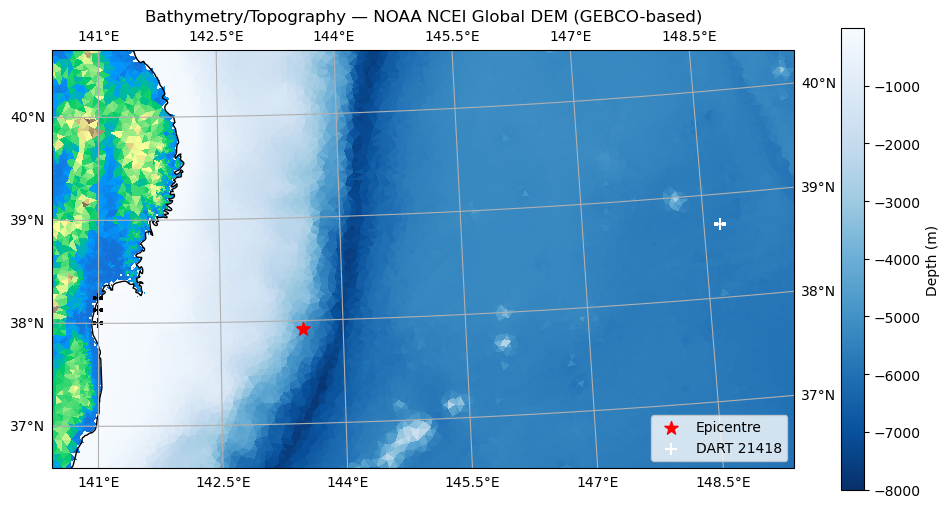

In [8]:
import cartopy.crs as ccrs

dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

md = 0.01  # wet/dry threshold

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

ax.set_extent([450_000, 1_400_000, 4_050_000, 4_500_000], crs=ccrs.UTM(zone=54))

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='Blues_r')
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='+', color='k', s=60,
               transform=ccrs.UTM(zone=54))

ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Depth (m)')
plt.title('Bathymetry/Topography — NOAA NCEI Global DEM (GEBCO-based)')
plt.tight_layout()

## Apply Earthquake Deformation

Generate a KL realisation of the slip field and compute the resulting
Okada surface deformation.  Re-run this cell to draw a new sample.

In [9]:
x = domain.centroid_coordinates[:, 0]
y = domain.centroid_coordinates[:, 1]

uE, uN, uZ, slips = okl.kl_deformation(
    x, y,
    xoff=x0 - xll,
    yoff=y0 - yll,
    E_subfault=10,
    N_subfault=10,
    sample='sobol',
    iseed=1234,
    **fault_parameters,
)

Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values

Elevation[:] += uZ
Stage[:]     += uZ

print(f'uZ range   : {uZ.min():.2f} m to {uZ.max():.2f} m')
print(f'Stage range: {Stage.min():.2f} m to {Stage.max():.2f} m')

uZ range   : -8.79 m to 18.88 m
Stage range: -8.79 m to 1831.95 m


## Initial Stage After Deformation

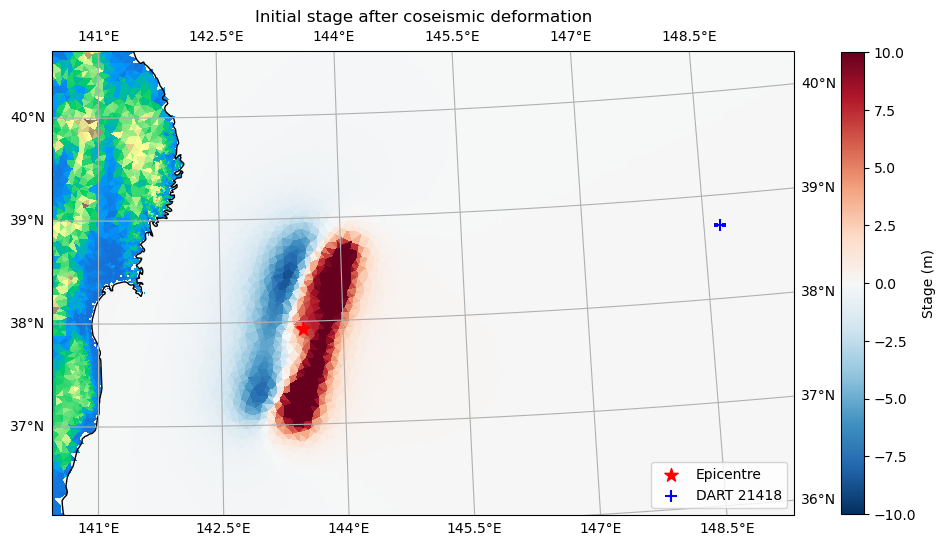

In [10]:
dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.stage, cmap='RdBu_r', vmin=-10, vmax=10)
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='b', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')

#ax.set_extent([450000, 1000000, 4050000, 4500000], crs=ccrs.UTM(zone=54))
ax.set_extent([450_000, 1_400_000, 4_000_000, 4_500_000], crs=ccrs.UTM(zone=54))
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Stage (m)')
plt.title('Initial stage after coseismic deformation')
plt.tight_layout()

## Boundary Conditions and Evolve

In [11]:
Br = anuga.Reflective_boundary(domain)
Bf = anuga.Flather_external_stage_zero_velocity_boundary(domain, lambda t: tide)

domain.set_boundary({
    'onshore':    Br,
    'bottom':     Bf,
    'ocean_east': Bf,
    'top':        Bf,
})

In [12]:
#from anuga.operators.collect_max_quantities_operator import Collect_max_quantities_operator

#max_min_collector = Collect_max_quantities_operator(domain)
max_collector = domain.max_quantities_operator

In [13]:
import time

min_  = 60.
hour_ = 3600.

tid_21418 = domain.get_triangle_containing_point([gauges[21418].east, gauges[21418].north])
tid = {k: domain.get_triangle_containing_point([gauges[k].east, gauges[k].north])
       for k in [0, 1, 2]}

gauge_time  = []
stage_21418 = []
stage_coast = {k: [] for k in [0, 1, 2]}
speed_21418 = []
speed_coast = {k: [] for k in [0, 1, 2]}
speed_depth_21418 = []
speed_depth_coast =  {k: [] for k in [0, 1, 2]}

dplotter = anuga.Domain_plotter(domain, absolute=True)

t0 = time.time()

for t in domain.evolve(yieldstep=2 * min_, finaltime=2.0 * hour_):
    gauge_time.append(t)
    stage_21418.append(dplotter.stage[tid_21418])
    for k in [0, 1, 2]:
        stage_coast[k].append(dplotter.stage[tid[k]])
        
    speed_21418.append(dplotter.stage[tid_21418])
    for k in [0, 1, 2]:
        speed_coast[k].append(dplotter.speed[tid[k]])
        
    speed_depth_21418.append(dplotter.speed_depth[tid_21418])
    for k in [0, 1, 2]:
        speed_depth_coast[k].append(dplotter.speed_depth[tid[k]])
    domain.print_timestepping_statistics()

print(f'\nSimulation took {time.time() - t0:.1f} s')

Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=343MB
Time = 120.0000 (sec), delta t in [3.98664090, 3.98664466] (s), steps=31 (0s), elapsed (0s), eta (23s), mem=346MB
Time = 240.0000 (sec), delta t in [3.98664034, 3.98664093] (s), steps=31 (0s), elapsed (0s), eta (20s), mem=347MB
Time = 360.0000 (sec), delta t in [3.98663986, 3.98664033] (s), steps=31 (0s), elapsed (1s), eta (19s), mem=347MB
Time = 480.0000 (sec), delta t in [3.98663995, 3.98664209] (s), steps=31 (0s), elapsed (1s), eta (19s), mem=348MB
Time = 600.0000 (sec), delta t in [3.98664209, 3.98664229] (s), steps=31 (0s), elapsed (1s), eta (18s), mem=349MB
Time = 720.0000 (sec), delta t in [3.98664199, 3.98664225] (s), steps=31 (0s), elapsed (2s), eta (18s), mem=350MB
Time = 840.0000 (sec), delta t in [3.98664154, 3.98664199] (s), steps=31 (0s), elapsed (2s), eta (17s), mem=351MB
Time = 960.0000 (sec), delta t in [3.98664120, 3.98664154] (s), steps=31 (0s), elapsed (2s), eta (17s), mem=351MB
Time = 1080.0000 (s

## Maximum Stage

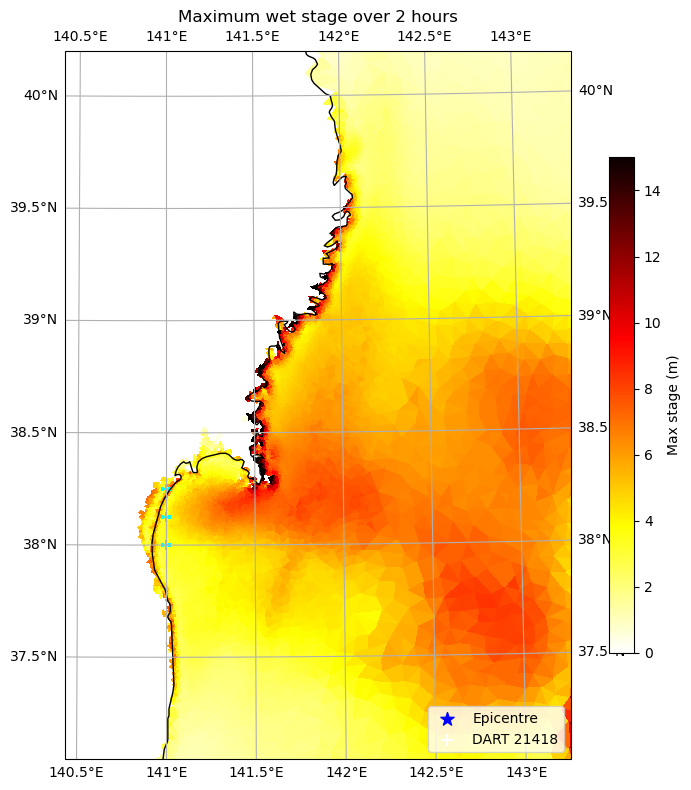

In [14]:
max_depth = max_collector.max_depth
max_stage = max_collector.max_stage
wet_max_stage = np.where(max_depth >= 0.01, max_stage, np.nan)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

img = ax.tripcolor(dplotter.triang, facecolors=wet_max_stage,
                   cmap='hot_r', vmin=0, vmax=15)

ax.scatter(x0, y0, marker='*', color='b', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='+', color='cyan', s=60,
               transform=ccrs.UTM(zone=54))

ax.set_extent([450000, 700000, 4100000, 4450000], crs=ccrs.UTM(zone=54))
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.7, label='Max stage (m)')
plt.title('Maximum wet stage over 2 hours')
plt.tight_layout()

## Nearshore Gauge Time Series

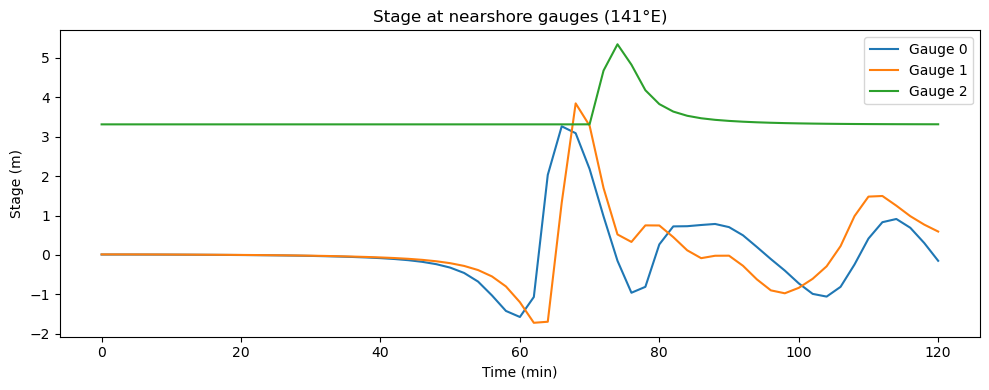

In [15]:
t = np.array(gauge_time)

fig, ax = plt.subplots(figsize=(10, 4))
# for k in [0, 1, 2]:
#     ax.plot(t / 60, stage_coast[k], label=f'Gauge {k}')
for k in [0, 1, 2]:
    ax.plot(t / 60, stage_coast[k], label=f'Gauge {k}')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('Stage at nearshore gauges (141°E)')
plt.tight_layout()

## Comparison with DART 21418 Observations

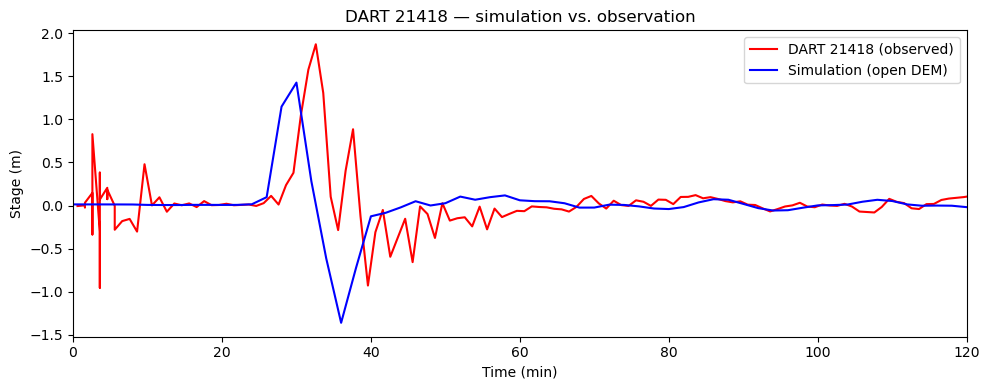

In [16]:
obs = np.loadtxt('21418_notide.txt')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(obs[:, 0] / 60, obs[:, 1], 'r', label='DART 21418 (observed)')
ax.plot(t / 60, stage_21418, 'b', label='Simulation (open DEM)')
ax.set_xlim(0, 120)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('DART 21418 — simulation vs. observation')
plt.tight_layout()